# Beispiele

In [2]:
# Import
import numpy as np
import sklearn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, RocCurveDisplay, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## Beispiel: Cheap and Expensive Bearings

<div>
    <img src=attachment:2a6aa928-e8db-420d-87b1-86ed2764fc29.png width=120>
</div>

Stellen Sie sich vor Sie würden in einem Maschinenbauunternehmen arbeiten. An allen Ecken und Enden sind Kugellager verschiedenster Arten verbaut - teuere große, billige kleine. Sie haben mit Ihrem Datenanalyseteam ein Machine Learning Modell (`bearing_model.pkl`) erzeugt, das die Klassifikation von Kugellager aller Arten in "gut" und "beschädigt" auf zufriedenstellende Weise durchführen kann. Nun will Ihr Vorgesetzter aber einerseits vermeiden, dass Sie die teuren Kugellager __zu häufig fälschlicherweise__, die billigen __zu selten zum richtigen Zeitpunkt__ auswechseln. Für Ihren Vorgesetzten bedeutet Ersteres `fpr~0.023`, und Letzteres `tpr~0.97`. Bauen Sie Ihrem Vorgesetzten hierzu eine Funktion, die Ihnen ein trainiertes Modell `model` und einen Testdatensatz `Xtest` aufnehmen kann. Die Funktion soll die angepassten Vorhersagen `ypredicted_new` zurückgeben und in einer ROC-Kurve markieren, an welchem Punkt es sich mit seiner neuen Einstellung befindet. Welche Eingabeargumente benötigen wir noch, um die unterschiedliche Behandlung von `fpr` und `tpr` zu berücksichtigen?
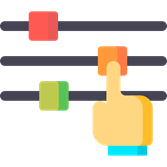

### Generate data

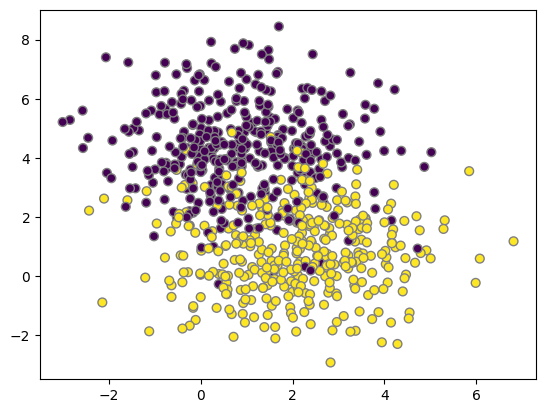

In [2]:
X, y = make_blobs(n_samples=1000, centers=2,
                       cluster_std=1.5, random_state=0)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y)

# Plot
plt.figure();
plt.scatter(Xtrain[:, 0], Xtrain[:, 1], c=ytrain, s=40, cmap='viridis', edgecolors='gray');

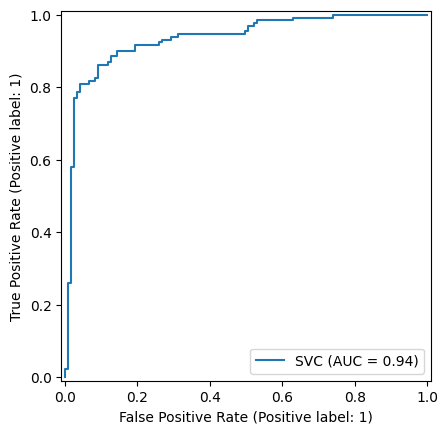

In [3]:
# Train some classifier
model = SVC().fit(Xtrain, ytrain)
yscore = model.decision_function(Xtest)

# Compute ROC
fpr, tpr, thresholds = roc_curve(ytest, yscore)
RocCurveDisplay.from_estimator(model, Xtest, ytest);

In [4]:
cross_val_score(model, Xtrain, ytrain).mean()

np.float64(0.884)

In [5]:
# Save
joblib.dump(model, './../res/data/bearing_model.pkl')
np.save('./../res/data/bearing_xtest.npy', Xtest)
np.save('./../res/data/bearing_ytest.npy', ytest)

### Lösung

In [5]:
# Load model and test split
model = joblib.load('./../res/data/bearing_model.pkl')
Xtest = np.load('./../res/data/bearing_xtest.npy')
ytest = np.load('./../res/data/bearing_ytest.npy')

C:\Users\gom39655\AppData\Local\anaconda3\envs\KS_new\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
# Function
def adjusted_predict(model, Xtest, ytest, tpfp_value, tp=True):
    """
    
    """
    
    # Get score for thresholding
    yscore = model.decision_function(Xtest)

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(ytest, yscore)

    # Adjust for TP or FP
    if tp:
        tpfpr = tpr
    else:
        tpfpr = fpr

    # Get sought after threshold
    
    index_of_tpfp_value = np.argmin(np.abs(tpfpr - tpfp_value))
    threshold = thresholds[index_of_tpfp_value]

    # Plot ROC curve with marked threshold
    plt.plot([0,1], [0,1], linestyle='--', label='No Skill')
    plt.plot(fpr, tpr, marker='.', label='Model')
    plt.scatter(fpr[index_of_tpfp_value], tpr[index_of_tpfp_value], marker='o', color='black', label='searched')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend();

    # Return decision-threshold-adjusted predictions
    return yscore > threshold


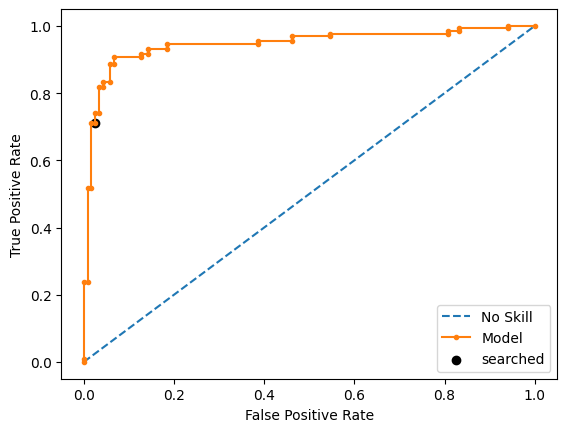

In [7]:
ypredicted_new = adjusted_predict(model, Xtest, ytest, 0.023, tp=False)

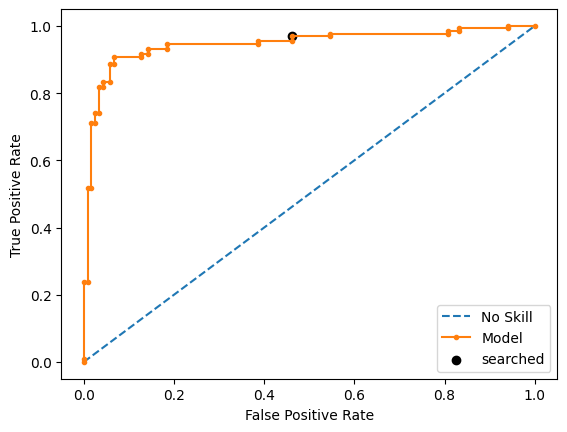

In [8]:
ypredicted_new = adjusted_predict(model, Xtest, ytest, 0.97, tp=True)

### Beispiel: _What_ confuses our models?

<div>
    <img src=attachment:a2acd39d-69a5-4afd-a518-a07228a20815.png width=300>
</div>

Wir laden uns die Modelle verschiedener vergangener Aufgaben und lassen uns die Confusion Matrix mittels einer `sns.heatmap` visualisieren. Welche Klassen können unsere Modelle am besten, welche am wenigsten auseinanderhalten?
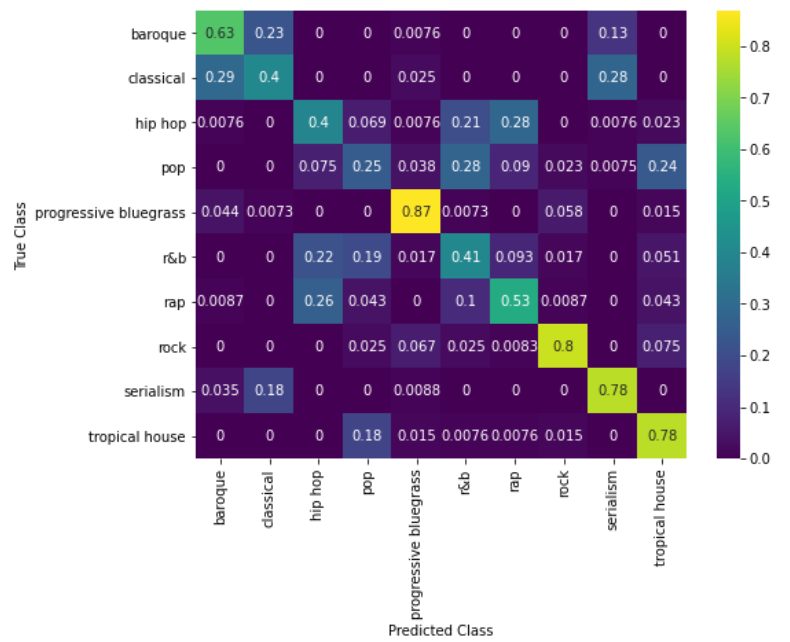

In [5]:
# Load model: bearing 10 classes
ytest = np.load('./../res/data/bearing_10classes_ytest.npy')
ypredicted = np.load('./../res/data/bearing_10classes_ypredicted.npy')
classes = ['B007_3', 'B014_3', 'B021_3', 'IR007_3', 'IR014_3', 'IR021_3', 
           'normal', 'OR007@6_3', 'OR014@6_3', 'OR021@6_3']

In [10]:
# Load model: face recognition
ytest = np.load('./../res/data/face_recognition_ytest.npy')
ypredicted = np.load('./../res/data/face_recognition_ypredicted.npy')
classes = ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush',
           'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair']

In [11]:
# Load model: spotify, svm
ytest = np.load('./../res/data/spotify_svm_ytest.npy', allow_pickle=True)
ypredicted = np.load('./../res/data/spotify_svm_ypredicted.npy', allow_pickle=True)
classes = ['baroque',
        'classical',
        'hip hop',
        'pop',
        'progressive bluegrass',
        'r&b',
        'rap',
        'rock',
        'serialism',
        'tropical house']

In [3]:
# Load model: spotify, random forest
ytest = np.load('./../res/data/spotify_rf_ytest.npy', allow_pickle=True)
ypredicted = np.load('./../res/data/spotify_rf_ypredicted.npy', allow_pickle=True)
classes = ['baroque',
        'classical',
        'hip hop',
        'pop',
        'progressive bluegrass',
        'r&b',
        'rap',
        'rock',
        'serialism',
        'tropical house']

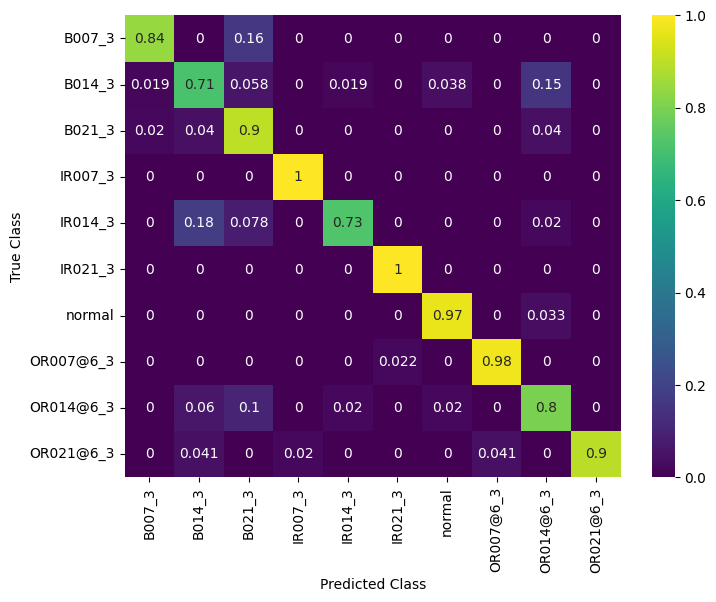

In [6]:
# Show confusion matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(ytest, ypredicted, normalize='true')
sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes, cmap='viridis')
plt.ylabel('True Class')
plt.xlabel('Predicted Class');

# Quellen

<div>
    <img src=attachment:dabb097f-60e5-4451-b920-7fbb13b9c348.png width=100>
</div>
<div>Icons made by <a href="https://www.freepik.com" title="Freepik">Freepik</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a></div>
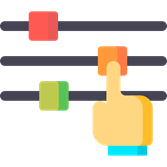